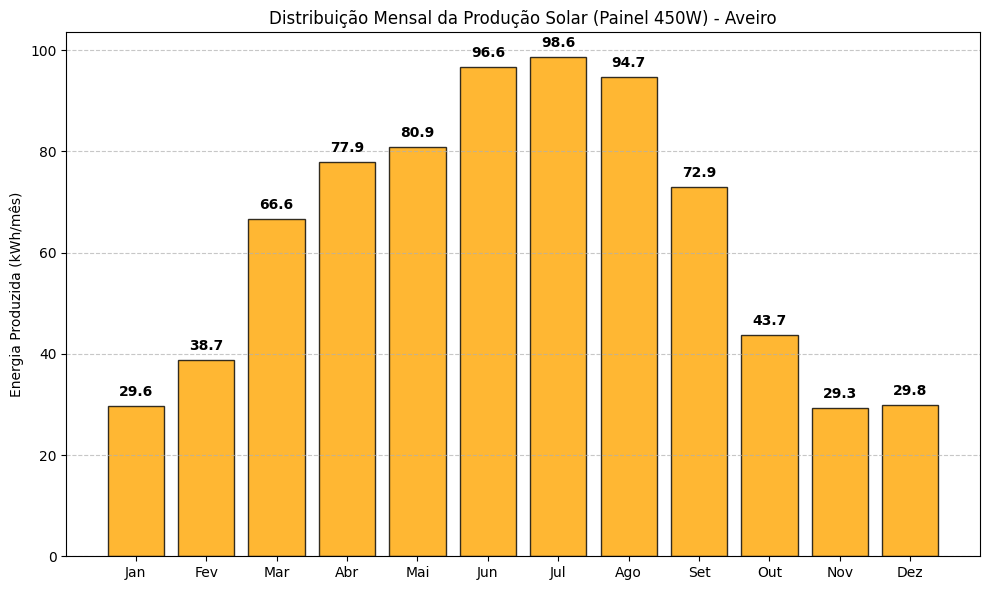

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carregar dados TMY
df = pd.read_csv(r'raw/tmy_40.593_-8.585_2005_2023.csv', skiprows=17, nrows=8760)

# 2. Conversão e Cálculo
df['time(UTC)'] = pd.to_datetime(df['time(UTC)'], format='%Y%m%d:%H%M')
df['G(h)'] = pd.to_numeric(df['G(h)'], errors='coerce')

# Cálculo para painel de 450W (0.45 kWp)
df['producao_kwh'] = (df['G(h)'] / 1000) * 0.450

# 3. Agrupamento por Mês
monthly_prod = df.groupby(df['time(UTC)'].dt.month)['producao_kwh'].sum()
meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

# 4. Gráfico de Barras Mensal
plt.figure(figsize=(10, 6))
plt.bar(meses, monthly_prod, color='orange', edgecolor='black', alpha=0.8)
plt.title('Distribuição Mensal da Produção Solar (Painel 450W) - Aveiro')
plt.ylabel('Energia Produzida (kWh/mês)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras
for i, v in enumerate(monthly_prod):
    plt.text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('producao_mensal.png')


Foi criada uma série temporal que representa a produção de energia ao longo de vários meses utilizando os dados da série temporal Typical Meteorological Year (TMY) que obtém os melhores valores de irradiação ao longo de vários anos e atribui a cada mês este valor. Com estes dados foi criada a série temporal ilustrada na imagem acima e com isso conseguimos cosntatar e confirmar que nos meses de verão (junho, julho e agosto) a produção de energia solar atinge os seus valores mais altos. O mês de julho é o que apresenta maior valor de produção energética com 98.6 kWh/mês e o pior mês de produção corresponde ao mês de novembro com 29.3 kWh/mês.

Esta constatação evidencia o efeito da sazonalidade ao longo do ano porque meses mais quentes (verão) apresentam maior produção de energia e meses mais frios (inverno) apresentam valores mais baixos.

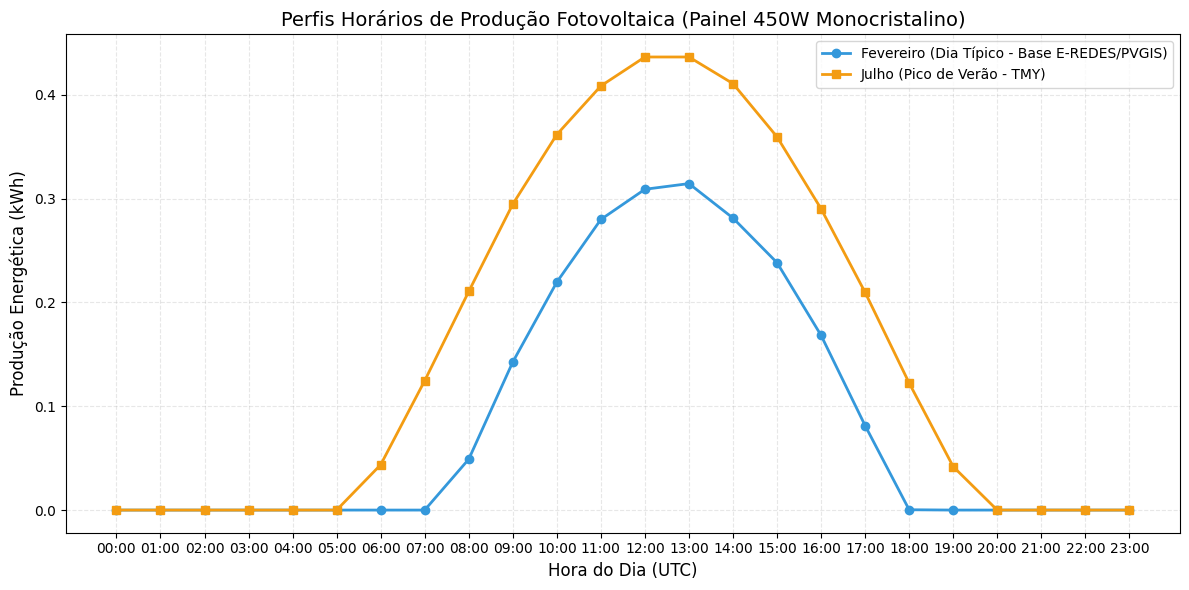

Produção Diária Total (Fevereiro): 2.08 kWh
Produção Diária Total (Julho): 3.75 kWh


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definição de Parâmetros Técnicos
POTENCIA_PAINEL_KWP = 0.450  # Painel de 450W (Standard Industrial)

# 2. Carregamento e Processamento dos Dados
# A. Dados de um dia típico de Fevereiro (Ficheiro Dailydata)
df_feb = pd.read_csv(r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\consumo_prod\Dailydata_40.641_-8.652_SA3_02_34deg_0deg.csv", 
                     sep='\t', skiprows=7, skipfooter=1, engine='python')
df_feb.columns = [c.strip() for c in df_feb.columns] # Limpeza de colunas
df_feb['prod_kwh'] = (df_feb['G(i)'] / 1000) * POTENCIA_PAINEL_KWP

# B. Dados do Ano Meteorológico Típico (Ficheiro TMY) - Para comparação com Verão
df_tmy = pd.read_csv(r"C:\Users\carol\OneDrive\Desktop\Carolina\Carolina\raw\tmy_40.593_-8.585_2005_2023.csv", skiprows=17, nrows=8760)
df_tmy['time(UTC)'] = pd.to_datetime(df_tmy['time(UTC)'], format='%Y%m%d:%H%M')
df_tmy['prod_kwh'] = (df_tmy['G(h)'] / 1000) * POTENCIA_PAINEL_KWP

# Extrair um dia representativo de Julho (ex: dia 15)
dia_julho = df_tmy[(df_tmy['time(UTC)'].dt.month == 7) & (df_tmy['time(UTC)'].dt.day == 15)]

# 3. Visualização dos Perfis Horários
plt.figure(figsize=(12, 6))

# Perfil Fevereiro
plt.plot(df_feb['time(UTC)'], df_feb['prod_kwh'], 
         label='Fevereiro (Dia Típico - Base E-REDES/PVGIS)', 
         color='#3498db', marker='o', linewidth=2)

# Perfil Julho
plt.plot(range(24), dia_julho['prod_kwh'], 
         label='Julho (Pico de Verão - TMY)', 
         color='#f39c12', marker='s', linewidth=2)

# Configurações do Gráfico
plt.title('Perfis Horários de Produção Fotovoltaica (Painel 450W Monocristalino)', fontsize=14)
plt.xlabel('Hora do Dia (UTC)', fontsize=12)
plt.ylabel('Produção Energética (kWh)', fontsize=12)
plt.xticks(range(24))
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('perfis_horarios_producao.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Cálculo de Totais Diários para Validação
print(f"Produção Diária Total (Fevereiro): {df_feb['prod_kwh'].sum():.2f} kWh")
print(f"Produção Diária Total (Julho): {dia_julho['prod_kwh'].sum():.2f} kWh")

Além da análise mensal, a série temporal permitiu a construção de perfis horários de produção. Ao cruzar estes dados com o consumo real obtido através do portal da E-REDES (fevereiro de 2024), identificou-se o fenómeno de mismatch energético: o desfasamento entre o pico de produção solar (situado entre as 12:00 e as 14:00 UTC) e os picos de consumo residencial (registados habitualmente entre as 19:00 e as 21:00).
Este cenário enfatiza a importância do nosso projeto e o problema que o mesmo tenta resolver.
